In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Mini Project/OSIC Pulmonary Fibrosis Progression"))

['osic-pulmonary-fibrosis-progression.zip', 'Chest X-Ray Images (Pneumonia).zip', 'chest_xray']


In [ ]:
import zipfile
import os

# ✅ DEFINE THIS FIRST
zip_path = "/content/drive/MyDrive/Mini Project/Chest X-Ray Images (Pneumonia)/Chest X-Ray Images (Pneumonia).zip"

# ✅ WHERE TO EXTRACT
extract_path = "/content/drive/MyDrive/Mini Project/Chest X-Ray Images (Pneumonia)/"

# ✅ EXTRACT
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [ ]:
data_path = "/content/drive/MyDrive/Mini Project/OSIC Pulmonary Fibrosis Progression/chest_xray"

In [ ]:
import os
print(os.listdir(data_path))

['__MACOSX', 'chest_xray', 'test', 'train']


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=data_path + "/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=data_path + "/test",   # ✅ FIXED
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Train size: 2831


In [ ]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
model = CNNModel().to(device)

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # GPU usage

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 34.0043
Epoch 2, Loss: 11.9373
Epoch 3, Loss: 7.9268
Epoch 4, Loss: 7.7194
Epoch 5, Loss: 6.6949


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 79.33%


In [ ]:
from torchvision import models

model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


In [ ]:
import torch.nn as nn

model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes
model = model.to(device)

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # smaller LR for ResNet

In [ ]:
epochs = 3   # reduce time

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 9.3616
Epoch 2, Loss: 1.8837
Epoch 3, Loss: 1.2344


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 85.90%


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
dataiter = iter(val_loader)
images, labels = next(dataiter)

image = images[0].unsqueeze(0).to(device)  # single image
label = labels[0]

print("Actual Label:", label.item())

Actual Label: 0


In [ ]:
target_layer = model.layer4

In [ ]:
gradients = []
activations = []

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

def forward_hook(module, input, output):
    activations.append(output)

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [ ]:
output = model(image)
pred_class = output.argmax(dim=1)

model.zero_grad()
output[0, pred_class].backward()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [ ]:
grads = gradients[0].cpu().data.numpy()[0]
acts = activations[0].cpu().data.numpy()[0]

weights = np.mean(grads, axis=(1, 2))

cam = np.zeros(acts.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * acts[i]

cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224))
cam = cam - np.min(cam)
cam = cam / np.max(cam)

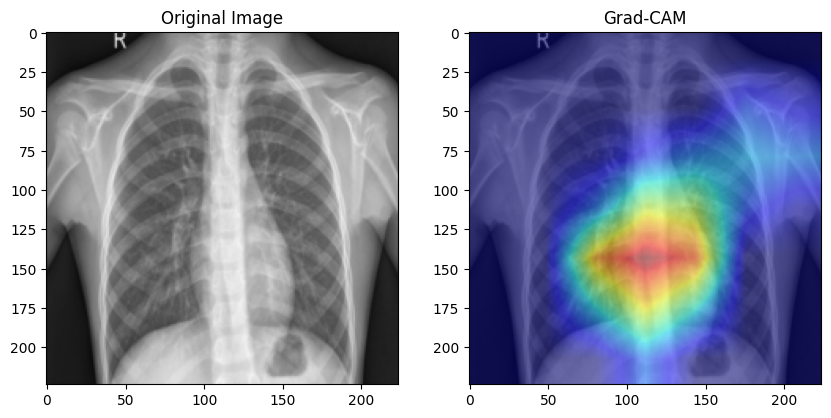

In [ ]:
img = images[0].permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Grad-CAM")
plt.imshow(img, cmap='gray')
plt.imshow(cam, cmap='jet', alpha=0.5)

plt.show()

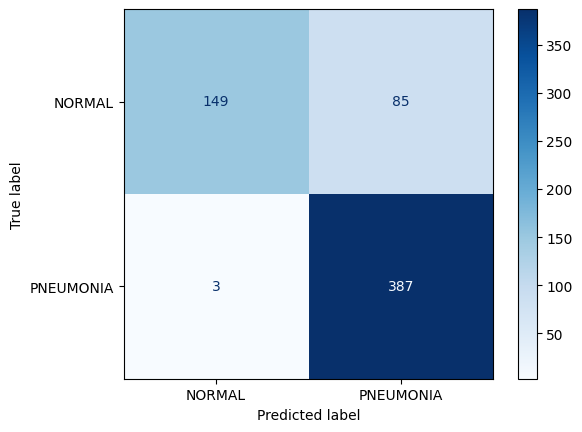

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NORMAL', 'PNEUMONIA'])
disp.plot(cmap='Blues')
plt.show()